# ST2195 Coursework — Part 1: Metropolis-Hastings MCMC

**Target Distribution:**  
$$f(x) = \frac{1}{2}e^{-|x|}, \quad x \in \mathbb{R}$$
This is a **Laplace (double exponential)** distribution with location 0 and scale 1.
- Theoretical mean: $0$
- Theoretical variance: $2$ → standard deviation $\sqrt{2} \approx 1.4142$

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)

print("Libraries loaded successfully.")

Libraries loaded successfully.


## Helper Functions

In [5]:
def log_f(x):
    """Log of target density: log f(x) = -|x| - log(2)"""
    return -np.abs(x) - np.log(2)


def f(x):
    """Target density: f(x) = 0.5 * exp(-|x|)"""
    return 0.5 * np.exp(-np.abs(x))


def metropolis_hastings(N, s, x0=0.0):
    """
    Random Walk Metropolis-Hastings algorithm.

    Parameters
    ----------
    N  : int   – number of steps (returns x0, x1, ..., xN)
    s  : float – standard deviation of Normal proposal
    x0 : float – initial value

    Returns
    -------
    numpy array of shape (N+1,) containing x0, x1, ..., xN
    """
    x = np.zeros(N + 1)
    x[0] = x0
    for i in range(1, N + 1):
        x_star = np.random.normal(x[i - 1], s)
        log_r = log_f(x_star) - log_f(x[i - 1])
        log_u = np.log(np.random.uniform())
        # Accept if log(u) < log(r)  — equivalent to u < r but numerically stable
        if log_u < log_r:
            x[i] = x_star
        else:
            x[i] = x[i - 1]
    return x

---
## Part (a): Simulation with N = 10 000, s = 1

Run the algorithm and produce:
1. A histogram of the generated samples
2. A kernel density estimate (KDE)
3. The true density $f(x)$ overlaid
4. The Monte Carlo estimates of mean and standard deviation

In [6]:
N = 10_000
s = 1.0
x0 = 0.0

np.random.seed(42)
samples_full = metropolis_hastings(N, s, x0)
samples = samples_full[1:]  # x1, ..., xN  (exclude x0 as instructed)

print(f"Generated {len(samples)} samples (x1 to x{N}).")

Generated 10000 samples (x1 to x10000).


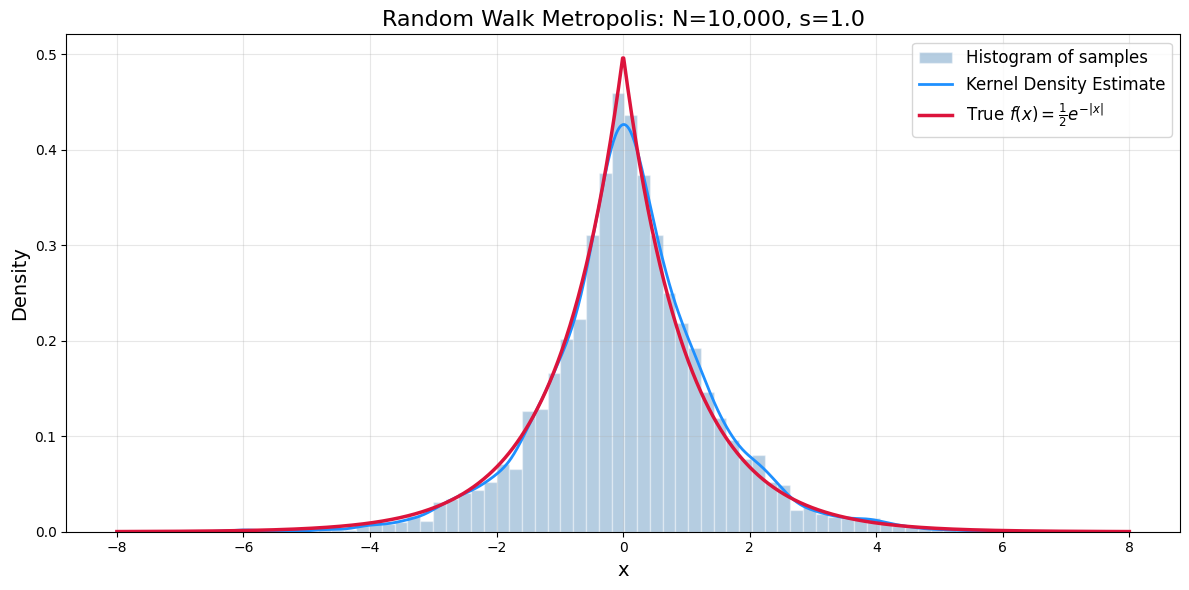

Saved: part1a_plot.png


In [7]:
x_plot = np.linspace(-8, 8, 1000)
true_density = f(x_plot)
kde = gaussian_kde(samples)

fig, ax = plt.subplots(figsize=(12, 6))

# Histogram
ax.hist(samples, bins=60, density=True, alpha=0.40,
        color='steelblue', edgecolor='white', label='Histogram of samples')

# KDE
ax.plot(x_plot, kde(x_plot), color='dodgerblue', linewidth=2.0,
        label='Kernel Density Estimate')

# True f(x)
ax.plot(x_plot, true_density, color='crimson', linewidth=2.5,
        label=r'True $f(x)=\frac{1}{2}e^{-|x|}$')

ax.set_xlabel('x', fontsize=14)
ax.set_ylabel('Density', fontsize=14)
ax.set_title(f'Random Walk Metropolis: N={N:,}, s={s}', fontsize=16)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('part1a_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: part1a_plot.png")

In [8]:
sample_mean = np.mean(samples)
sample_std  = np.std(samples, ddof=1)
acceptance_rate = np.mean(np.diff(samples_full) != 0)

print("=" * 52)
print("  Monte Carlo Estimates — Part 1(a)")
print("=" * 52)
print(f"  Sample Mean:          {sample_mean:+.6f}")
print(f"  Theoretical Mean:      0.000000")
print()
print(f"  Sample Std Dev:        {sample_std:.6f}")
print(f"  Theoretical Std Dev:   {np.sqrt(2):.6f}   [sqrt(2)]")
print()
print(f"  Acceptance Rate:       {acceptance_rate:.4f}")
print("=" * 52)

  Monte Carlo Estimates — Part 1(a)
  Sample Mean:          +0.079114
  Theoretical Mean:      0.000000

  Sample Std Dev:        1.316062
  Theoretical Std Dev:   1.414214   [sqrt(2)]

  Acceptance Rate:       0.7075


---
## Part (b): Gelman-Rubin $\hat{R}$ Convergence Diagnostic

Given $J$ chains, each of length $N$ (excluding $x_0$), the diagnostic is:

$$M_j = \frac{1}{N}\sum_{i=1}^{N} x_i^{(j)}, \qquad
V_j = \frac{1}{N}\sum_{i=1}^{N}\bigl(x_i^{(j)} - M_j\bigr)^2$$

$$W = \frac{1}{J}\sum_{j=1}^{J} V_j, \qquad
M = \frac{1}{J}\sum_{j=1}^{J} M_j, \qquad
B = \frac{1}{J}\sum_{j=1}^{J}(M_j - M)^2$$

$$\hat{R} = \sqrt{\frac{B + W}{W}}$$

Convergence is indicated when $\hat{R} < 1.05$.

In [9]:
def compute_rhat(N, s, J, x0_values=None):
    """
    Compute the Gelman-Rubin R-hat statistic.

    Parameters
    ----------
    N         : int   – chain length (steps, excluding x0)
    s         : float – proposal std deviation
    J         : int   – number of chains
    x0_values : array-like of length J, initial values per chain

    Returns
    -------
    float : R-hat value
    """
    if x0_values is None:
        x0_values = np.random.uniform(-5, 5, J)

    chains = []
    for j in range(J):
        chain_full = metropolis_hastings(N, s, float(x0_values[j]))
        chains.append(chain_full[1:])   # x1, ..., xN

    # Chain means Mj
    Mj = np.array([np.mean(c) for c in chains])

    # Within-chain variances Vj  (use N in denominator as defined in coursework)
    Vj = np.array([np.mean((c - mj) ** 2) for c, mj in zip(chains, Mj)])

    # Within-sample variance W
    W = np.mean(Vj)

    # Overall mean M and between-chain variance B
    M = np.mean(Mj)
    B = np.mean((Mj - M) ** 2)

    if W < 1e-12:
        return np.inf

    return np.sqrt((B + W) / W)


print("compute_rhat() defined.")

compute_rhat() defined.


In [10]:
# Fixed parameters for Part (b)
N_b = 2000
J   = 4
s_fixed = 0.001

# Spread initial values to stress-test convergence
x0_values = [-5.0, -2.0, 2.0, 5.0]

np.random.seed(42)
rhat_fixed = compute_rhat(N_b, s_fixed, J, x0_values)

print(f"R-hat for N={N_b}, s={s_fixed}, J={J}: {rhat_fixed:.4f}")
if rhat_fixed < 1.05:
    print("  → Convergence achieved (R-hat < 1.05)")
else:
    print(f"  → NOT converged (R-hat ≥ 1.05) — chains mixing poorly for s={s_fixed}")

R-hat for N=2000, s=0.001, J=4: 168.5009
  → NOT converged (R-hat ≥ 1.05) — chains mixing poorly for s=0.001


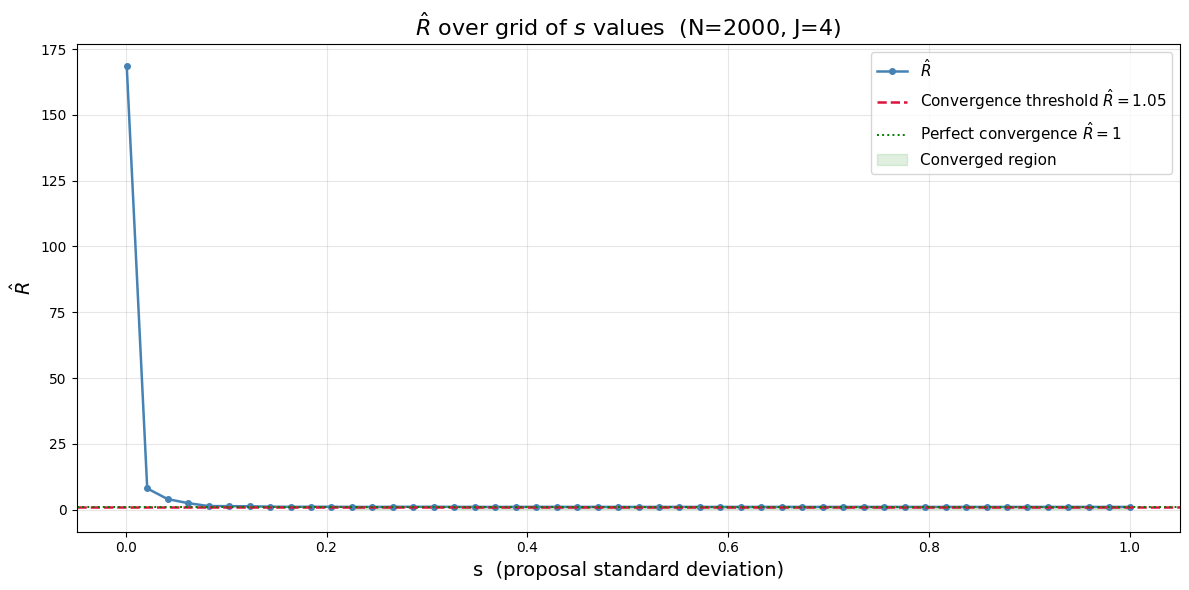

Saved: part1b_plot.png


In [11]:
np.random.seed(42)

s_grid = np.linspace(0.001, 1.0, 50)
rhat_values = np.array([compute_rhat(N_b, s_val, J, x0_values) for s_val in s_grid])

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(s_grid, rhat_values, color='steelblue', linewidth=1.8,
        marker='o', markersize=4, label=r'$\hat{R}$')

ax.axhline(1.05, color='crimson', linestyle='--', linewidth=1.8,
           label=r'Convergence threshold $\hat{R}=1.05$')
ax.axhline(1.00, color='green', linestyle=':', linewidth=1.4,
           label=r'Perfect convergence $\hat{R}=1$')

# Shade converged region
converged_mask = rhat_values < 1.05
if converged_mask.any():
    ax.fill_between(s_grid, 0, rhat_values,
                    where=converged_mask, alpha=0.12, color='green',
                    label='Converged region')

ax.set_xlabel('s  (proposal standard deviation)', fontsize=14)
ax.set_ylabel(r'$\hat{R}$', fontsize=14)
ax.set_title(rf'$\hat{{R}}$ over grid of $s$ values  (N={N_b}, J={J})', fontsize=16)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('part1b_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: part1b_plot.png")

In [12]:
converged_s = s_grid[rhat_values < 1.05]

print(f"S values achieving convergence (R-hat < 1.05):")
if len(converged_s) > 0:
    print(f"  [{converged_s[0]:.4f}, {converged_s[-1]:.4f}]")
else:
    print("  None in tested range.")

print(f"\nR-hat summary over s grid:")
print(f"  min R-hat = {rhat_values.min():.4f}  at s = {s_grid[rhat_values.argmin()]:.4f}")
print(f"  max R-hat = {rhat_values.max():.4f}  at s = {s_grid[rhat_values.argmax()]:.4f}")

S values achieving convergence (R-hat < 1.05):
  [0.1641, 1.0000]

R-hat summary over s grid:
  min R-hat = 1.0004  at s = 0.8777
  max R-hat = 168.5009  at s = 0.0010
